# Lesson 11 — Subgraphs: Composing Graphs Inside Graphs

## What you will learn
- How to build a **subgraph** and use it as a node in a parent graph
- How **state keys are shared** between parent and subgraph (matching key names)
- Why subgraphs = **reusable, testable, team-owned modules**
- How to run **parallel subgraphs** with `Send()`

## Mental model
```
Parent Graph:
  START → generate → [validate subgraph] → [clean subgraph] → publish → END
                                         ↘ reject → END

Validate subgraph (internal):
  START → check_length → check_forbidden → check_format → END

Clean subgraph (internal):
  START → clean_whitespace → fix_capitalization → add_punctuation → END
```

> **Key insight:** A subgraph is compiled once and reused exactly like a regular node.
> State keys with matching names are **automatically shared**.

In [ ]:
# Install dependencies if needed
# !pip install langgraph langchain-ollama

## Step 1 — Subgraph 1: Validation Module

This subgraph is **self-contained and independently testable**.
It checks: length ≥ 10 chars, no forbidden words, starts with capital letter.

In [1]:
from typing import Annotated
from typing_extensions import TypedDict
from langchain_ollama import ChatOllama
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.types import Send
import sys
import os
if '..' not in sys.path:
    sys.path.append(os.path.abspath('..'))

from config import get_ollama_model

llm = ChatOllama(model=get_ollama_model(), temperature=0)

class ValidationState(TypedDict):
    content:           str
    is_valid:          bool
    validation_errors: list

def check_length(state: ValidationState) -> dict:
    errors = list(state.get("validation_errors", []))
    if len(state["content"].strip()) < 10:
        errors.append("Content too short (minimum 10 characters)")
        return {"is_valid": False, "validation_errors": errors}
    return {"is_valid": True, "validation_errors": errors}

def check_forbidden_words(state: ValidationState) -> dict:
    FORBIDDEN = ["spam", "scam", "fake", "misleading"]
    errors = list(state.get("validation_errors", []))
    found = [w for w in FORBIDDEN if w in state["content"].lower()]
    if found:
        errors.append(f"Contains forbidden words: {found}")
        return {"is_valid": False, "validation_errors": errors}
    return {"validation_errors": errors}

def check_format(state: ValidationState) -> dict:
    errors = list(state.get("validation_errors", []))
    if not state["content"][0].isupper():
        errors.append("Content must start with a capital letter")
        return {"is_valid": False, "validation_errors": errors}
    return {"validation_errors": errors}

v_builder = StateGraph(ValidationState)
v_builder.add_node("check_length",   check_length)
v_builder.add_node("check_forbidden", check_forbidden_words)
v_builder.add_node("check_format",   check_format)
v_builder.add_edge(START, "check_length")
v_builder.add_edge("check_length",   "check_forbidden")
v_builder.add_edge("check_forbidden", "check_format")
v_builder.add_edge("check_format",   END)
validation_subgraph = v_builder.compile()

print("Validation subgraph compiled!")

Validation subgraph compiled!


## Step 2 — Test the Validation Subgraph in Isolation

Before embedding in a parent graph, test independently. This is the subgraph superpower.

In [2]:
tests = [
    {"content": "Hi",                              "is_valid": True, "validation_errors": []},
    {"content": "This product is spam.",           "is_valid": True, "validation_errors": []},
    {"content": "Great Python IDE for developers.","is_valid": True, "validation_errors": []},
]
for t in tests:
    r = validation_subgraph.invoke(t)
    print(f"'{t['content']}' → valid={r['is_valid']} | errors={r['validation_errors']}")

'Hi' → valid=False | errors=['Content too short (minimum 10 characters)']
'This product is spam.' → valid=False | errors=["Contains forbidden words: ['spam']"]
'Great Python IDE for developers.' → valid=True | errors=[]


## Step 3 — Subgraph 2: Clean & Format Module

In [3]:
class CleanState(TypedDict):
    content:       str
    clean_content: str

def clean_whitespace(state: CleanState) -> dict:
    return {"clean_content": " ".join(state["content"].split())}

def fix_capitalization(state: CleanState) -> dict:
    return {"clean_content": state["clean_content"].strip().capitalize()}

def add_punctuation(state: CleanState) -> dict:
    text = state["clean_content"].rstrip()
    if not text.endswith((".", "!", "?")):
        text += "."
    return {"clean_content": text}

c_builder = StateGraph(CleanState)
c_builder.add_node("clean",      clean_whitespace)
c_builder.add_node("capitalize", fix_capitalization)
c_builder.add_node("punctuate",  add_punctuation)
c_builder.add_edge(START,        "clean")
c_builder.add_edge("clean",      "capitalize")
c_builder.add_edge("capitalize", "punctuate")
c_builder.add_edge("punctuate",  END)
clean_subgraph = c_builder.compile()

# Quick test
r = clean_subgraph.invoke({"content": "  hello   world  ", "clean_content": ""})
print(f"Clean result: '{r['clean_content']}'")

Clean result: 'Hello world.'


## Step 4 — Parent Graph: Compose Both Subgraphs

**State key sharing rule:** any key in the parent state that has the **same name** as a key in the subgraph state is automatically passed in and returned.

Here `content`, `is_valid`, `validation_errors`, `clean_content` are all shared.

In [4]:
class ReviewState(TypedDict):
    messages:          Annotated[list, add_messages]
    content:           str   # shared with BOTH subgraphs
    is_valid:          bool  # shared with validation subgraph
    validation_errors: list  # shared with validation subgraph
    clean_content:     str   # shared with clean subgraph
    final_output:      str   # parent-only

def generate_node(state: ReviewState) -> dict:
    system = SystemMessage(content="Write a short 2-sentence product description. Be professional.")
    resp = llm.invoke([system] + state["messages"])
    return {"content": resp.content, "messages": [resp]}

def route_after_validation(state: ReviewState) -> str:
    return "clean" if state.get("is_valid", False) else "reject"

def publish_node(state: ReviewState) -> dict:
    return {"final_output": f"✅ PUBLISHED: {state['clean_content']}"}

def reject_node(state: ReviewState) -> dict:
    errors = state.get("validation_errors", [])
    return {"final_output": f"❌ REJECTED: {'; '.join(errors)}"}

builder = StateGraph(ReviewState)
builder.add_node("generate", generate_node)
builder.add_node("validate", validation_subgraph)  # ← subgraph AS a node
builder.add_node("clean",    clean_subgraph)       # ← subgraph AS a node
builder.add_node("publish",  publish_node)
builder.add_node("reject",   reject_node)

builder.add_edge(START,      "generate")
builder.add_edge("generate", "validate")
builder.add_conditional_edges("validate", route_after_validation, {"clean": "clean", "reject": "reject"})
builder.add_edge("clean",    "publish")
builder.add_edge("publish",  END)
builder.add_edge("reject",   END)

graph = builder.compile()
print("Parent graph compiled!")

Parent graph compiled!


## Step 5 — Visualize

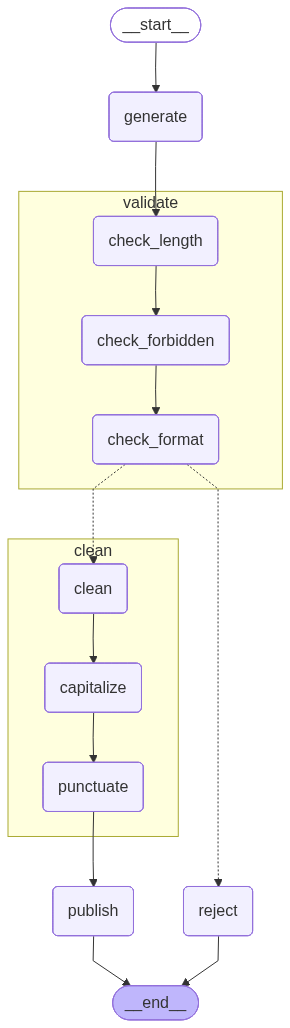

In [5]:
try:
    from IPython.display import Image, display
    display(Image(graph.get_graph(xray=True).draw_mermaid_png()))
except Exception as e:
    print(f"Visual rendering not available: {e}")
    print("Nodes:", list(graph.get_graph().nodes.keys()))

## Step 6 — Run the Parent Graph

In [6]:
result = graph.invoke({
    "messages": [HumanMessage(content="Write about our Python developer toolkit.")],
    "content": "", "is_valid": False, "validation_errors": [],
    "clean_content": "", "final_output": ""
})
print(f"Result: {result['final_output']}")

Result: ✅ PUBLISHED: Our python developer toolkit offers a comprehensive range of tools to streamline your development process, ensuring productivity and efficiency. with our python developer toolkit, you can streamline your workflow and reduce time spent on repetitive tasks.


## Step 7 — Parallel Subgraphs with Send()

`Send()` launches **independent subgraph executions in parallel** — one per topic.

In [7]:
class ParallelState(TypedDict):
    topics:    list
    summaries: Annotated[list, lambda x, y: x + y]

def summarize_node(state: dict) -> dict:
    topic = state["topic"]
    resp = llm.invoke([HumanMessage(content=f"In one sentence, define: {topic}")])
    return {"summaries": [f"{topic}: {resp.content}"]}

def parallel_fan_out(state: ParallelState):
    return [Send("summarize", {"topic": t}) for t in state["topics"]]

p_builder = StateGraph(ParallelState)
p_builder.add_node("summarize", summarize_node)
p_builder.add_conditional_edges(START, parallel_fan_out, ["summarize"])
p_builder.add_edge("summarize", END)
parallel_graph = p_builder.compile()

result = parallel_graph.invoke({"topics": ["LangGraph", "SQLite", "FastAPI", "Pydantic"], "summaries": []})
for s in result["summaries"]:
    print(f"  • {s[:120]}")

  • LangGraph: LangGraph is a graph-based tool used in computational linguistics to analyze and model language structures, f
  • SQLite: SQLite is a lightweight, open-source relational database system designed for storing and managing structured dat
  • FastAPI: FastAPI is a modern web framework that simplifies API development by leveraging Python's standard library, offe
  • Pydantic: Pydantic is a Python library designed to map database models to Python classes, enabling efficient object-rela


## Key Takeaways

| Concept | Detail |
|---------|--------|
| `validation_subgraph = v_builder.compile()` | Compiled subgraph is a runnable |
| `builder.add_node("validate", validation_subgraph)` | Subgraph used as a node |
| Matching key names | Automatically shared between parent ↔ subgraph |
| `xray=True` | Shows internal subgraph nodes in visualization |
| `Send("node", state)` | Launches parallel isolated executions |

## 🏋️ Exercise
1. Add a third subgraph: `sentiment_subgraph` that classifies `content` as positive/negative and sets `sentiment: str` in state
2. Insert it between `generate` and `validate` in the parent graph
3. If `sentiment == "negative"` → skip validate and go straight to `reject`

In [ ]:
# Your exercise solution here
